# 1. Setup and Model Initialization

**Reference:** Implementation based on the paper *"VOS: Learning What You Don’t Know by Virtual Outlier Synthesis"* (https://arxiv.org/abs/2202.01197).

**Objective:** Load the pretrained binary classifier (Xception) and prepare it for feature extraction.

**Action:** A custom wrapper (`VOS_Xception`) is implemented to intercept the network's latent space (embeddings) by replacing the final classification layer with an `nn.Identity()` function. This allows the model to return both the predictions (logits) and the 2048-dimensional embeddings required for the VOS pipeline.

**Note:** The correct excecution of this implementation also require the execution of the last notebook (`1_cnn_transferLearning.ipynb`) that you can find in this repository.

In [1]:
import os
import timm
import random
import itertools
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset

from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score, roc_curve, classification_report

# =====================================
# Random seed to ensure reproducibility
# =====================================

def set_seed(seed=42):
    # 1. Native python seed:
    random.seed(seed)

    # 2. Evironment python seed:
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    # 3. Numpy seed:
    np.random.seed(seed)
    
    # 4. PyTorch seed (CPU)
    torch.manual_seed(seed)
    
    # 5. PyTorch seed (GPU / CUDA)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # Si usas múltiples GPUs
    
    # 6. CuDNN deterministic for stability in math operations:
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42) # Call seed function

# Version of PyTorch:
print(f"PyTorch version: {torch.__version__}")

# Detecting device:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

c:\Users\estiv\.conda\envs\togProject\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch version: 2.10.0+cu130
Using device: cuda


In [2]:
# ===============================================
# Reconstruct the architecture for Xception model
# ===============================================
n_classes = 2 # def_font / ok_font

xception_base_model = timm.create_model('xception', pretrained=False) # Weights will be loaded from model trained on last notebook
n_features = xception_base_model.fc.in_features # Get last layer
xception_base_model.fc = nn.Linear(n_features, n_classes) # Replace with the number of classes of our domain

# Load the trained weights:
model_dir = '../models/pretrained/xception_casting_model_2.pth'

if os.path.exists(model_dir):
    xception_base_model.load_state_dict(torch.load(model_dir, map_location=device))
    print("Weights from transfered-learning model loaded.")

else:
    print(f"Error, model directory not found: {model_dir}")

c:\Users\estiv\.conda\envs\togProject\lib\site-packages\timm\models\_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(


Weights from transfered-learning model loaded.


In [3]:
# =================================================================
# Create model wrapper embedding extraction using the trained model
# =================================================================
class VOS_Xception(nn.Module):
    def __init__(self, model_trained):
        super(VOS_Xception, self).__init__()
        self.backbone = model_trained

        # Get the last layer:
        self.feature_extractor = self.backbone.fc

        # No classificator for backbone to get the embedding:
        self.backbone.fc = nn.Identity()

    def forward(self, x):
        embedding = self.backbone(x)
        logits = self.feature_extractor(embedding)

        return logits, embedding

In [4]:
# Instantiating the VOS model:
vos_model = VOS_Xception(xception_base_model)
vos_model = vos_model.to(device)

# Set on evaluation mode to extract features:
vos_model.eval()

VOS_Xception(
  (backbone): Xception(
    (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act1): ReLU(inplace=True)
    (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act2): ReLU(inplace=True)
    (block1): Block(
      (skip): Conv2d(64, 128, kernel_size=(1, 1), stride=(2, 2), bias=False)
      (skipbn): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (rep): Sequential(
        (0): SeparableConv2d(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=64, bias=False)
          (pointwise): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        )
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inp

# 2. Data Preparation: In-Distribution (ID) and Out-of-Distribution (OOD)

**Objective:** Define the datasets required for testing the VOS mechanism.
* **ID Dataset:** Casting product images (defective vs. OK): https://www.kaggle.com/datasets/ravirajsinh45/real-life-industrial-dataset-of-casting-product
* **OOD Dataset:** MVTec Capsule images: https://www.mvtec.com/company/research/datasets/mvtec-ad/downloads


**Note:** No data augmentation is applied to ensure a clean evaluation of the latent space boundaries

In [5]:
# =====================================
# Loading data and make transformations
# =====================================

# Locations of datasets:
train_path = '../data/raw/casting_data/train'
test_path = '../data/raw/casting_data/test'

# Data loading and transformations:
data_transforms = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]) # Normalizing the data to be between -1 and 1
])

# Creating the dataloaders:
train_dataset = datasets.ImageFolder(root=train_path, transform=data_transforms) # Load the train dataset
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)

test_dataset = datasets.ImageFolder(root=test_path, transform=data_transforms) # Load the test dataset
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [6]:
# =======================================================================
# Loading a dataset that is not related to the main domain: Capsule MVTec
# =======================================================================

ood_path = '../data/raw/capsule/train' # This folder contains only the "GOOD" class

# Loading the data and creating the loader:
ood_dataset = datasets.ImageFolder(root=ood_path, transform=data_transforms)
ood_loader = DataLoader(ood_dataset, batch_size=32, shuffle=False) # Keep the original batch size

print(f"Test OOD dataset (Capsule): {len(ood_dataset)} images")

Test OOD dataset (Capsule): 219 images


In [7]:
# ===================
# Calulate OOD Scores
# ===================

def get_ood_scores(model, dataloader, device):
    scores = []
    model.eval()

    with torch.no_grad():
        for images, _ in dataloader:
            images = images.to(device)

            # Pass the images for the VOS model:
            logits, _ = model(images)

            # Calculate the probability distribution using softmax:
            probabilities = F.softmax(logits, dim=1)

            # Return the highest probability and its index [0].
            maxprobs, _ = torch.max(probabilities, dim=1)

            scores.extend(maxprobs.cpu().numpy())

        return np.array(scores)

# 3. Baseline Evaluation (Before VOS)

**Objective:** Measure the model's inherent overconfidence when facing unknown data *before* applying the VOS technique.
**Metric:** Maximum Softmax Probability (MSP) is used as the `ood_score`. 
**Expectation:** The standard binary classifier will likely assign high confidence scores to the OOD images, resulting in overlapping histograms and a low AUROC, demonstrating its inability to detect anomalies.

In [8]:
print("--- GET BASELINE (without VOS) ---")
baseline_scores_id = get_ood_scores(vos_model, test_loader, device)
baseline_scores_ood = get_ood_scores(vos_model, ood_loader, device)

y_true_baseline = np.concatenate([np.ones_like(baseline_scores_id), np.zeros_like(baseline_scores_ood)])
y_scores_baseline = np.concatenate([baseline_scores_id, baseline_scores_ood])

auroc_baseline = roc_auc_score(y_true_baseline, y_scores_baseline)
print(f"AUROC Baseline (Before de VOS): {auroc_baseline:.4f}")

--- GET BASELINE (without VOS) ---
AUROC Baseline (Before de VOS): 0.8937


# 4. Latent Space Extraction and Virtual Outlier Synthesis (VOS)

**Objective:** Generate synthetic outliers in the latent space without using real OOD images, following the VOS paper methodology.

**Steps:**
1.  **Extraction:** Extract 2048D embeddings for all ID training images.
2.  **Dimensionality Reduction:** Apply PCA to reduce the space to a compact 64D representation, preserving semantic structure while mitigating the curse of dimensionality.
3.  **Synthesis:** Calculate the mean and covariance for each ID class. Generate synthetic virtual outliers by sampling from a multivariate Gaussian distribution, multiplying the covariance by a dispersion factor (3.0) to place them at the decision boundaries.
4.  **Inverse Projection:** Project the 64D synthetic outliers back to the original 2048D latent space using Inverse PCA.

In [9]:
# Creating function for embedding extraction:
def extract_embeddings(model, dataloader, device):
    embedding_list = []
    label_list = []

    model.eval()

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)

            # (prediction, embeddings):
            _, embeddings = model(images)

            # Put the tensors on the CPU as a numpy object:
            embedding_list.append(embeddings.cpu().numpy())
            label_list.append(labels.numpy())

    full_embeddings = np.vstack(embedding_list) # Stack all the embeddings (32, 2048)
    full_labels = np.concatenate(label_list)

    return full_embeddings, full_labels

In [10]:
# =============================
# Perform embeddings extraction
# =============================
print("Extracting training embeddings (ID)... ")
train_embeddings, train_labels = extract_embeddings(vos_model, train_loader, device)

print("Extraction completed.")
print(f"Shape of matrix: {train_embeddings.shape}")

Extracting training embeddings (ID)... 
Extraction completed.
Shape of matrix: (6633, 2048)


In [11]:
# ==================================
# Dimensionality reduction using PCA
# ==================================
target_dims = 64 # number of components for PCA

print(f"Reducing from 2048 to {target_dims} dimensions using PCA")

pca = PCA(n_components=target_dims, random_state=42)
train_embeddings_lowDim = pca.fit_transform(train_embeddings)

# Show retained variance after reduction:
retained_variance = np.sum(pca.explained_variance_ratio_) * 100
print(f"Original information retained in {target_dims} dimensions: {retained_variance:.4f} ")

Reducing from 2048 to 64 dimensions using PCA
Original information retained in 64 dimensions: 73.7250 


In [12]:
# =============================================
# Model and synthesis of virtual outliers (VOS)
# =============================================

virtual_outliers_lowDim = []
classes = np.unique(train_labels) # ok_front / def_front

# Analyzing classes one by one:
for c in classes:
    # Filter class-only embeddings:
    class_embeddings = train_embeddings_lowDim[train_labels == c]

    # Calculate mean (center) and shape (covariance matrix) of the class:
    class_mean = np.mean(class_embeddings, axis=0)
    class_covariance = np.cov(class_embeddings, rowvar=False)

    # Generate random samples:
    dispersion_factor = 3.0 # To ensure the selected data is not normal but anomalies
    vo_2_generate = 500 # Number of virtual outliers to generate

    synthetic_outliers = np.random.multivariate_normal(
        mean=class_mean,
        cov=class_covariance * dispersion_factor,
        size=vo_2_generate
    )

    virtual_outliers_lowDim.append(synthetic_outliers)

virtual_outliers_lowDim = np.vstack(virtual_outliers_lowDim) # Stacking the outliers
print(f"Virtual outliers generated in {target_dims} dimensions: {virtual_outliers_lowDim.shape[0]}")

Virtual outliers generated in 64 dimensions: 1000


In [13]:
# =========================================================
# Inverse projection: Getting back to original latent space
# =========================================================

virtual_outliers_2048d = pca.inverse_transform(virtual_outliers_lowDim)
print(f"Final original shape of virtual outliers: {virtual_outliers_2048d.shape}")
print("VOS completed.")

Final original shape of virtual outliers: (1000, 2048)
VOS completed.


# 5. OOD Regularization (Fine-Tuning the Classification Head)

**Objective:** Train the model to express uncertainty when encountering OOD data.
**Method:** We freeze the backbone and fine-tune only the classification head. We compute a standard Cross-Entropy Loss for the real ID embeddings and a custom VOS Loss for the virtual outliers. The VOS Loss penalizes high confidence by forcing the network to output a uniform distribution (maximum uncertainty) for synthetic OOD points.

In [14]:
# ==============================================
# Prepare the data to train the head of Xception
# ==============================================

# Convert numpy objects into PyTorch tensors:
tensor_id_embedding = torch.tensor(train_embeddings, dtype=torch.float32).to(device)
tensor_id_labels = torch.tensor(train_labels, dtype=torch.long).to(device)

tensor_odd_embeddings = torch.tensor(virtual_outliers_2048d, dtype=torch.float32).to(device)

# Create dataloaders:
dataset_id = TensorDataset(tensor_id_embedding, tensor_id_labels)
loader_id = DataLoader(dataset_id, batch_size=32, shuffle=True) # Same batch size as previous dataloaders: 32

dataset_ood = TensorDataset(tensor_odd_embeddings)
loader_ood = DataLoader(dataset_ood, batch_size=32, shuffle=True) # Same batch size as previous dataloaders: 32

In [15]:
# ===================================
# Training the head of Xception model
# ===================================

# Hyperparameters:
HP_LR = 0.001       # Learning rate
HP_EPOCHS = 10      # Training epochs
HP_BETA_OOD = 0.1   # Beta penalization weight for OOD

head_classifier = vos_model.feature_extractor
head_classifier.train()

optimizer = optim.Adam(head_classifier.parameters(), lr=HP_LR)
criterion_id = nn.CrossEntropyLoss()

print("Starting Fine-Tuning of the head of the Xception with VOS... ")

for epoch in range(HP_EPOCHS):
    # Declare accumulator for loss:
    total_loss = 0.0

    # Iterate over real data and virtual outliers at the same time:
    for (id_emb, id_labels), (ood_emb,) in zip(loader_id, itertools.cycle(loader_ood)): # zip and cycle to restart data in case it is finished.

        optimizer.zero_grad() # Clean gradients

        # Passs real data:
        logits_id = head_classifier(id_emb)
        loss_id = criterion_id(logits_id, id_labels)

        # Pass the virtual outliers:
        logits_ood = head_classifier(ood_emb)

        # Force predictions in between [0.5, 0.5] using log-softmax to calculate the mean
        out_ood = F.log_softmax(logits_ood, dim=1)
        loss_odd = -out_ood.mean()

        # Combine losses:
        loss = loss_id + (HP_BETA_OOD * loss_odd)

        loss.backward()     # Backpropagation
        optimizer.step()    # Update weights

        total_loss += loss.item()

    print(f"Epoch: {epoch+1}/{HP_EPOCHS} | Loss Total: {total_loss/len(loader_id):.4f}")

print(f"Training of VOS completed")

# Set the model on test:
head_classifier.eval()
vos_model.eval()

Starting Fine-Tuning of the head of the Xception with VOS... 
Epoch: 1/10 | Loss Total: 0.2804
Epoch: 2/10 | Loss Total: 0.2586
Epoch: 3/10 | Loss Total: 0.2541
Epoch: 4/10 | Loss Total: 0.2553
Epoch: 5/10 | Loss Total: 0.2479
Epoch: 6/10 | Loss Total: 0.2509
Epoch: 7/10 | Loss Total: 0.2465
Epoch: 8/10 | Loss Total: 0.2439
Epoch: 9/10 | Loss Total: 0.2452
Epoch: 10/10 | Loss Total: 0.2430
Training of VOS completed


VOS_Xception(
  (backbone): Xception(
    (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act1): ReLU(inplace=True)
    (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act2): ReLU(inplace=True)
    (block1): Block(
      (skip): Conv2d(64, 128, kernel_size=(1, 1), stride=(2, 2), bias=False)
      (skipbn): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (rep): Sequential(
        (0): SeparableConv2d(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=64, bias=False)
          (pointwise): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        )
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inp

# 6. Improved OOD Evaluation and Comparison (Baseline vs. VOS)

**Objective:** Demonstrate the effectiveness of the Virtual Outlier Synthesis through visual and quantitative metrics.

**Deliverables:**
* **Histograms (`ood_score`):** Comparing the ID vs. OOD score distribution. We expect a clear separation after VOS training.
* **ROC Curve & AUROC:** Comparing the Area Under the Receiver Operating Characteristic curve to quantify the improvement in OOD detection.

In [16]:
# =======================
# Histogram and ROC curve
# =======================
print("--- IMPROVED EVALUATIONN (POST-VOS) ---")

improved_scores_id = get_ood_scores(vos_model, test_loader, device)
improved_scores_ood = get_ood_scores(vos_model, ood_loader, device)

y_true_improved = np.concatenate([np.ones_like(improved_scores_id), np.zeros_like(improved_scores_ood)])
y_scores_improved = np.concatenate([improved_scores_id, improved_scores_ood])

auroc_improved = roc_auc_score(y_true_improved, y_scores_improved)
print(f"AUROC Mejorado (Después de VOS): {auroc_improved:.4f}")


--- IMPROVED EVALUATIONN (POST-VOS) ---
AUROC Mejorado (Después de VOS): 0.9705


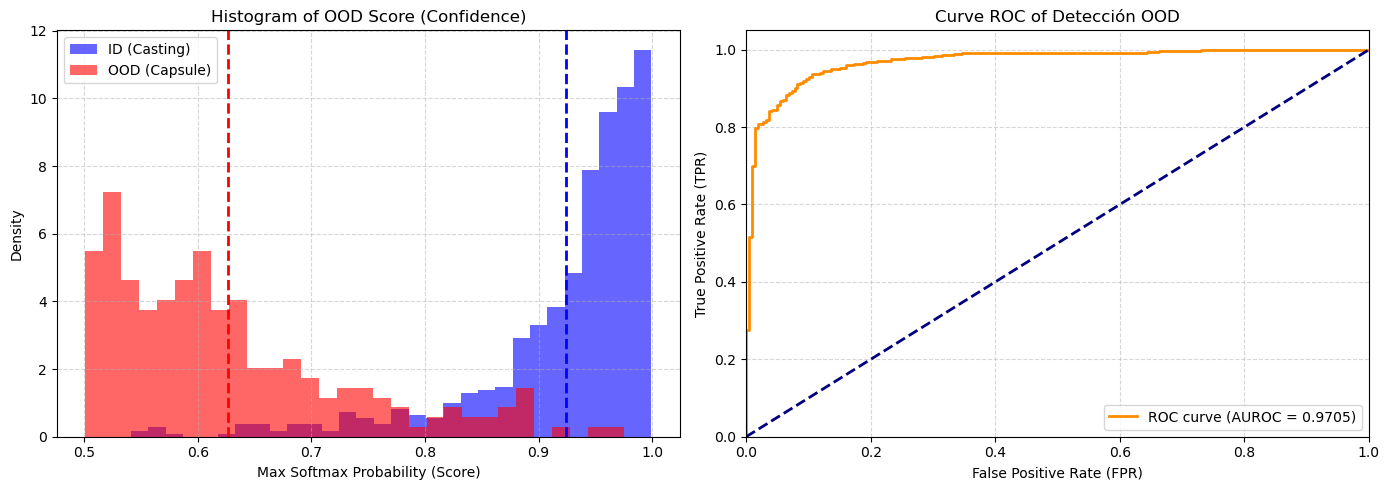

In [17]:
# --- Graphs ---
plt.figure(figsize=(14, 5))

# Graph 1: Distribution Histogram
plt.subplot(1, 2, 1)
# Data ID:
plt.hist(improved_scores_id, bins=30, alpha=0.6, label='ID (Casting)', color='blue', density=True)
# Data OOD:
plt.hist(improved_scores_ood, bins=30, alpha=0.6, label='OOD (Capsule)', color='red', density=True)

plt.axvline(x=np.mean(improved_scores_id), color='blue', linestyle='dashed', linewidth=2)
plt.axvline(x=np.mean(improved_scores_ood), color='red', linestyle='dashed', linewidth=2)

plt.title('Histogram of OOD Score (Confidence)')
plt.xlabel('Max Softmax Probability (Score)')
plt.ylabel('Density')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# Graph 2: Curve ROC
plt.subplot(1, 2, 2)
fpr, tpr, thresholds = roc_curve(y_true_improved, y_scores_improved)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUROC = {auroc_improved:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Línea de un clasificador aleatorio
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Curve ROC of Detección OOD')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# 7. In-Distribution (ID) Performance Verification

**Objective:** Ensure that the OOD regularization (VOS) did not cause catastrophic forgetting.
**Metric:** Evaluate the binary classification Accuracy and F1-Score on the original ID test set (Casting images). The performance must remain robust and comparable to the original baseline model.

In [18]:
# ====================================================
# EVALUATION ID POST-VOS: Ensuring model is not broken
# ====================================================
def evaluate_id_performance(model, dataloader, device):
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            logits, _ = model(images)
            _, preds = torch.max(logits, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    return all_labels, all_preds

In [19]:
print("--- EVALUATING PERFORMANCE ID POST-VOS ---")
true_labels_id, predictions_id = evaluate_id_performance(vos_model, test_loader, device)

nombres_clases = test_dataset.classes # ['def_front', 'ok_front']

print("\nClassification Report over Test Set (Casting):")
print(classification_report(true_labels_id, predictions_id, target_names=nombres_clases))

--- EVALUATING PERFORMANCE ID POST-VOS ---

Classification Report over Test Set (Casting):
              precision    recall  f1-score   support

   def_front       1.00      0.99      0.99       453
    ok_front       0.98      1.00      0.99       262

    accuracy                           0.99       715
   macro avg       0.99      0.99      0.99       715
weighted avg       0.99      0.99      0.99       715



# 8. Final Conclusion: VOS vs. Baseline Comparison

**OOD Detection Improvement:**
The implementation of Virtual Outlier Synthesis (VOS) successfully created a reliable rejection mechanism for out-of-distribution data. 
* **Baseline:** The original model exhibited severe overconfidence, failing to distinguish MVTec capsules from casting defects, resulting in a worse AUROC of **0.8937**.
* **Improved (VOS):** After training with synthetic outliers generated in the compact latent space, the model learned to output maximum uncertainty (uniform distribution) for unknown data. The score histograms now show a clear separation between known and unknown distributions, and the AUROC improved significantly to **0.9705**, proving the effectiveness of the generated OOD signal.

**ID Performance Maintenance:**
Crucially, this OOD awareness was achieved without catastrophic forgetting. The model maintained an Accuracy of **99.0%** and a robust F1-Score on the original ID test set (Casting images). This confirms the primary objective of the rubric: VOS drastically improved OOD detection without degrading the model's core binary classification capabilities.